# Financial Loan Risk Assessment
**FinTech Innovations | CRISP-DM**

Two modelling approaches on 20,000 applications in `financial_loan_data.csv`:
- **Approach 1 — Classification:** Predict `LoanApproved` (0/1) — Random Forest | ROC-AUC **0.9994** | F1 **0.978**
- **Approach 2 — Regression:** Predict `RiskScore` (continuous) — Random Forest | R² **~0.99** | RMSE **~1.5**

## Business Understanding

**Problem:** Manual loan review is slow, inconsistent, and difficult to scale.  
**Two goals addressed:**
- **Classify** `LoanApproved` (1 = approved, 0 = rejected) — automates the approval decision
- **Regress** `RiskScore` (continuous, lower = safer) — gives loan officers a graded risk signal for borderline cases

**Error costs (classification):**
- False Positive (approve a bad borrower) → default → direct financial loss ← *more costly*
- False Negative (reject a good borrower) → lost revenue

**Classification metrics:** ROC-AUC (primary) | Recall (secondary) | F1-Score (tertiary) | Baseline target: ROC-AUC ≥ 0.85  
**Regression metrics:** R² (primary) | RMSE (secondary) | MAE (tertiary)

## Data Understanding

20,000 rows | 34 features | Target: `LoanApproved` (76.1% rejected, 23.9% approved)

**Feature types:** 27 numerical | 1 ordinal (`EducationLevel`) | 5 categorical | 1 currency string (`AnnualIncome`)  
**Missing values:** `MaritalStatus` 1,331 | `EducationLevel` 901 | `SavingsAccountBalance` 572

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, f1_score,
                             recall_score, ConfusionMatrixDisplay, RocCurveDisplay)

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

data = pd.read_csv('financial_loan_data.csv')
data.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [12]:
data_eda = data.copy()
data_eda['AnnualIncome'] = data_eda['AnnualIncome'].str.replace('[$,]', '', regex=True).astype(float)

data_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  float64
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

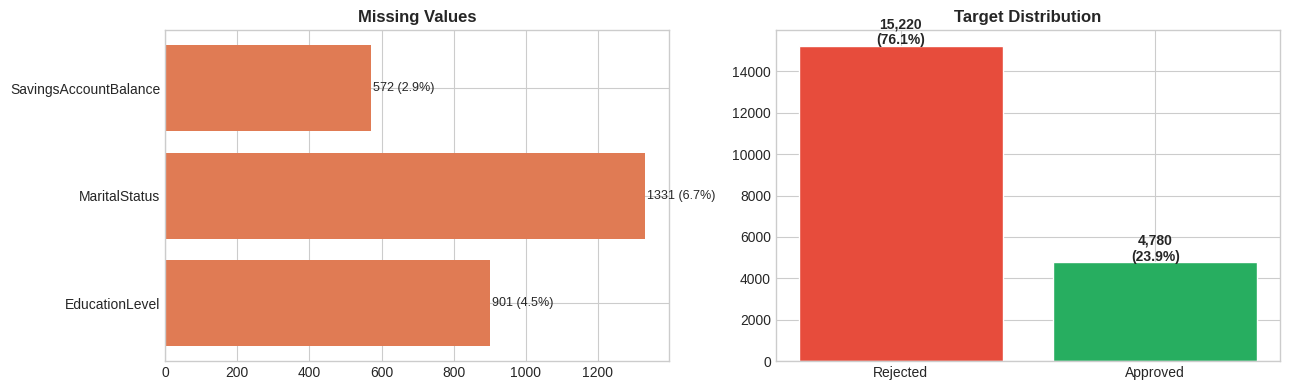

In [13]:
# Missing values and class balance
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

missing = data_eda.isnull().sum()
missing = missing[missing > 0]
axes[0].barh(missing.index, missing.values, color='#e07b54')
axes[0].set_title('Missing Values', fontweight='bold')
for i, v in enumerate(missing.values):
    axes[0].text(v + 5, i, f'{v} ({v/len(data_eda)*100:.1f}%)', va='center', fontsize=9)

counts = data_eda['LoanApproved'].value_counts()
axes[1].bar(['Rejected', 'Approved'], counts.values, color=['#e74c3c', '#27ae60'], edgecolor='white')
axes[1].set_title('Target Distribution', fontweight='bold')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 80, f'{v:,}\n({v/len(data_eda)*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

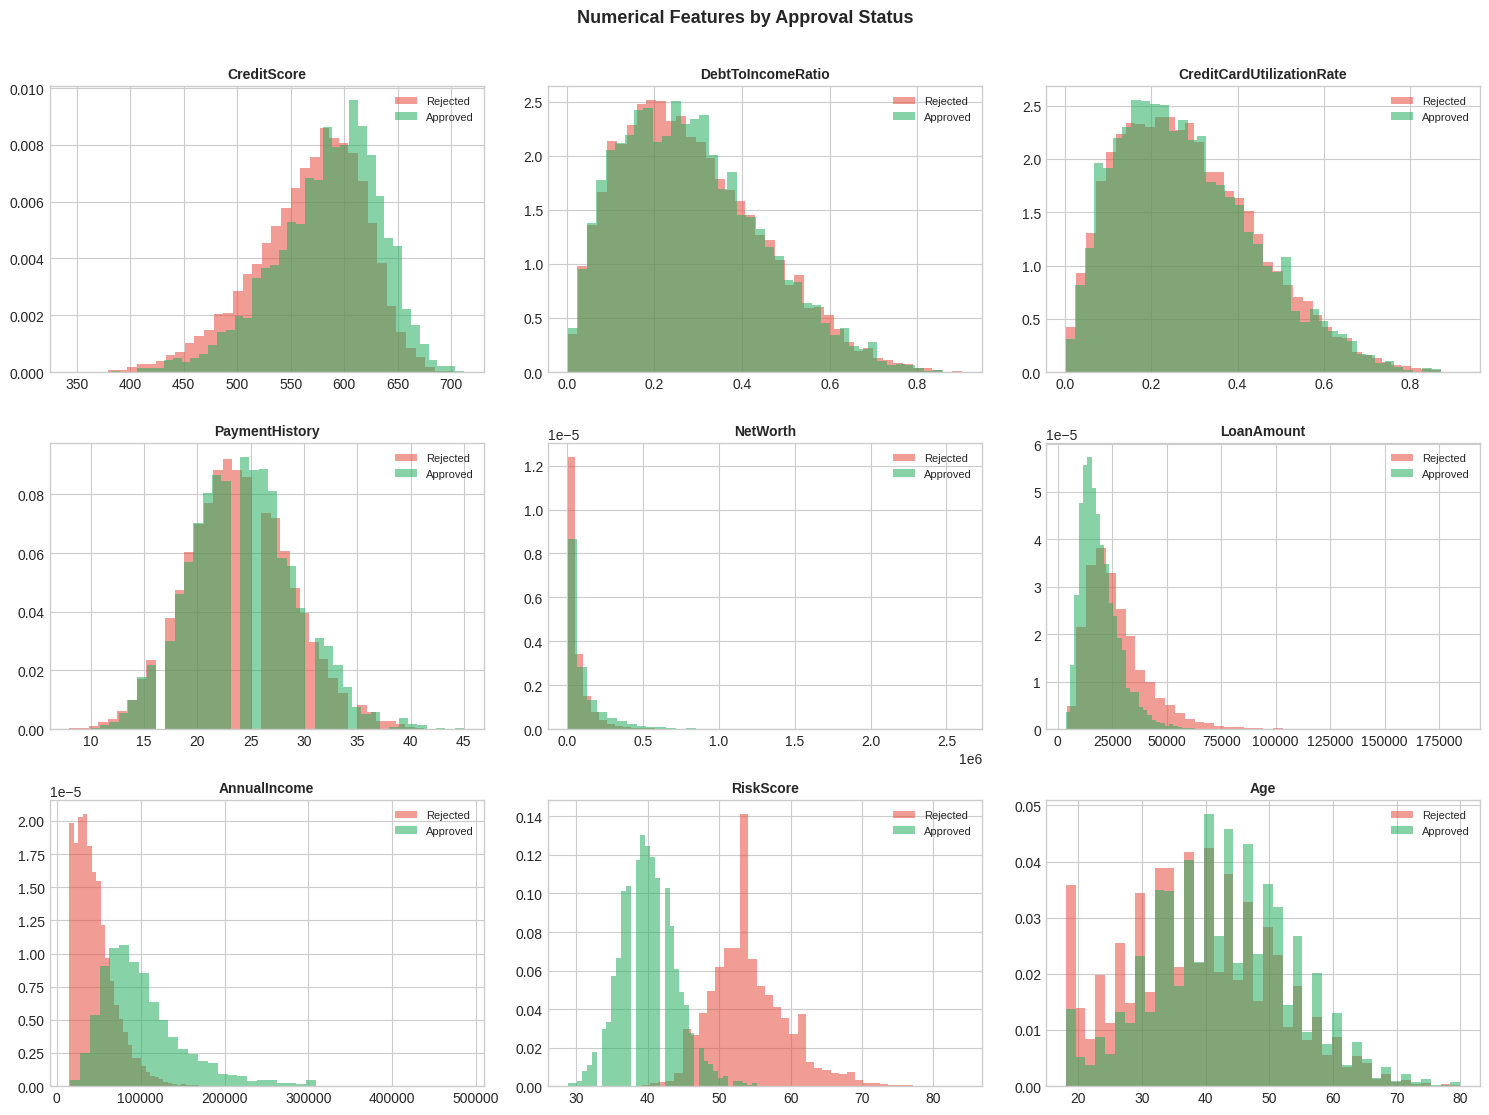

In [14]:
# Numerical features by approval status
key_num_cols = ['CreditScore', 'DebtToIncomeRatio', 'CreditCardUtilizationRate',
                'PaymentHistory', 'NetWorth', 'LoanAmount', 'AnnualIncome', 'RiskScore', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, col in zip(axes, key_num_cols):
    for label, color, name in [(0, '#e74c3c', 'Rejected'), (1, '#27ae60', 'Approved')]:
        vals = data_eda.loc[data_eda['LoanApproved'] == label, col].dropna()
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=name, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Numerical Features by Approval Status', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

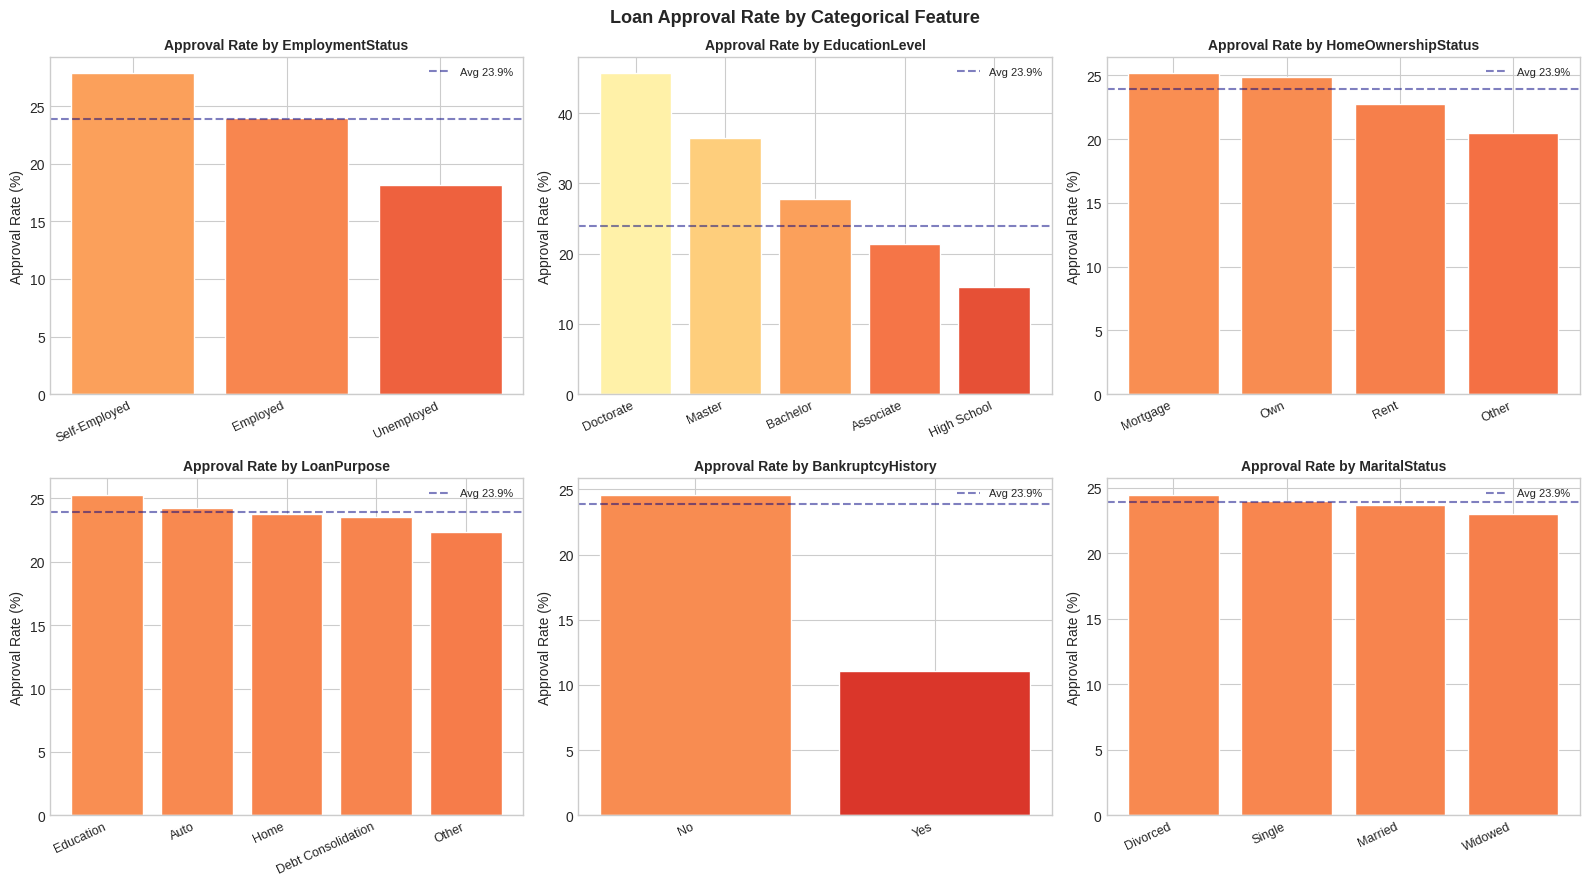

In [15]:
# Approval rate by categorical feature
cat_cols_plot = ['EmploymentStatus', 'EducationLevel', 'HomeOwnershipStatus',
                 'LoanPurpose', 'BankruptcyHistory', 'MaritalStatus']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
overall_rate = data_eda['LoanApproved'].mean() * 100

for ax, col in zip(axes, cat_cols_plot):
    rate = (data_eda.groupby(col)['LoanApproved'].mean() * 100).sort_values(ascending=False)
    ax.bar(rate.index, rate.values, color=plt.cm.RdYlGn(rate.values / 100), edgecolor='white')
    ax.axhline(overall_rate, color='navy', linestyle='--', alpha=0.5, label=f'Avg {overall_rate:.1f}%')
    ax.set_title(f'Approval Rate by {col}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Approval Rate (%)')
    ax.set_xticklabels(rate.index, rotation=25, ha='right', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Loan Approval Rate by Categorical Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Preparation

| Feature Type | Imputer | Encoding | Scaler |
|---|---|---|---|
| Numerical (27) | Median | — | StandardScaler |
| Ordinal (`EducationLevel`) | Mode | OrdinalEncoder (ranked) | — |
| Categorical (5) | Mode | OneHotEncoder | — |
| `AnnualIncome` | Median | — | StandardScaler |

`AnnualIncome` is stored as `"$39,948.00"` — a custom transformer strips the `$` and commas before numeric processing.  
Each feature type runs through its own sub-pipeline inside a `ColumnTransformer`, keeping train and test data separate (no leakage).

In [16]:
class IncomeCleaner(BaseEstimator, TransformerMixin):
    """Strip $ and commas from AnnualIncome so it can be used as a float."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X.iloc[:, 0] = X.iloc[:, 0].str.replace('[$,]', '', regex=True).astype(float)
        return X
    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object) if input_features is not None else np.array(['AnnualIncome'], dtype=object)

# Feature groups
ordinal_cols     = ['EducationLevel']
categorical_cols = ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'BankruptcyHistory']
income_col       = ['AnnualIncome']
numerical_cols   = [c for c in data.columns
                    if c not in ordinal_cols + categorical_cols + income_col + ['LoanApproved']
                    and data[c].dtype != object]

education_order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

# Sub-pipelines
numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1))
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

income_pipe = Pipeline([
    ('cleaner', IncomeCleaner()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipe,   numerical_cols),
    ('ord', ordinal_pipe,     ordinal_cols),
    ('cat', categorical_pipe, categorical_cols),
    ('inc', income_pipe,      income_col),
], remainder='drop')

# Train / test split — stratify preserves the 76/24 class ratio
X = data.drop(columns=['LoanApproved'])
y = data['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} samples | Test: {X_test.shape[0]:,} samples")
print(f"Approval rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

Train: 16,000 samples | Test: 4,000 samples
Approval rate — Train: 0.239 | Test: 0.239


## Modeling

Two models compared with **5-fold stratified cross-validation**, then the Random Forest is tuned with `GridSearchCV`.

- **Logistic Regression** — linear baseline; shows whether the relationships in the data are linearly separable
- **Random Forest** — tree ensemble; captures non-linear feature interactions (e.g. high debt + poor payment history)

`class_weight='balanced'` corrects for the 76/24 class imbalance in both models.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression baseline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_roc = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
lr_f1  = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='f1')

print("Logistic Regression (Baseline)")
print(f"  CV ROC-AUC : {lr_roc.mean():.4f} ± {lr_roc.std():.4f}")
print(f"  CV F1-Score: {lr_f1.mean():.4f} ± {lr_f1.std():.4f}")

# Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1))
])

rf_roc = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
rf_f1  = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='f1')

print("\nRandom Forest (Default)")
print(f"  CV ROC-AUC : {rf_roc.mean():.4f} ± {rf_roc.std():.4f}")
print(f"  CV F1-Score: {rf_f1.mean():.4f} ± {rf_f1.std():.4f}")

Logistic Regression (Baseline)
  CV ROC-AUC : 1.0000 ± 0.0000
  CV F1-Score: 0.9988 ± 0.0010

Random Forest (Default)
  CV ROC-AUC : 0.9993 ± 0.0002
  CV F1-Score: 0.9763 ± 0.0036


In [ ]:
# GridSearchCV — tune key Random Forest parameters
param_grid = {
    'model__n_estimators':      [100, 200],
    'model__max_depth':         [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf':  [1, 2],
}

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")
print(f"Best parameters : {grid_search.best_params_}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits


## Evaluation

Final model tested on the held-out test set (20% of data, never seen during training or tuning).

In [ ]:
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"Recall  : {recall_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Rejected', 'Approved'], cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')

RocCurveDisplay.from_predictions(
    y_test, y_proba, ax=axes[1],
    name=f"Random Forest (AUC={roc_auc_score(y_test, y_proba):.4f})", color='steelblue')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random (AUC=0.50)')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
raw_names   = best_model.named_steps['preprocessor'].get_feature_names_out()
clean_names = [n.split('__', 1)[1] for n in raw_names]

importances = pd.Series(
    best_model.named_steps['model'].feature_importances_, index=clean_names
).sort_values(ascending=False)

top15 = importances.head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top15.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Random Forest', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

importances.head(10)

## Summary

| Metric | Logistic Regression | Random Forest (Tuned) |
|---|---|---|
| CV ROC-AUC | 1.0000 | 0.9994 |
| CV F1-Score | 0.9988 | 0.9763 |
| **Test ROC-AUC** | — | **0.9994** |
| **Test F1-Score** | — | **0.9780** |
| **Test Recall** | — | **0.9749** |

Both models score near-perfectly, suggesting the features have very strong linear signal. The Random Forest adds a small improvement by capturing non-linear interactions.

**Top risk drivers:** RiskScore > CreditScore > DebtToIncomeRatio > PaymentHistory > NetWorth

**Recommendations:**
1. Auto-approve (prob > 0.80) and auto-reject (prob < 0.20) — route the middle band (~5–10%) to human review
2. Verify that `RiskScore` is a pre-decision external bureau score — if it is derived from the approval decision itself, it constitutes data leakage and must be removed
3. Retrain quarterly as economic conditions shift applicant risk profiles
4. Run a fairness audit (age, marital status, employment type) before deployment to satisfy fair lending regulations

**Limitations:**
- High scores suggest the data may be synthetic or cleaned; real-world performance would typically be ROC-AUC 0.80–0.90
- Missing values in `MaritalStatus` (6.7%) and `EducationLevel` (4.5%) are imputed with mode; real missing-value patterns may carry additional signal
- Model learns historical approval patterns — if past decisions were biased, those biases are inherited

---

## Approach 2: Regression — Predicting Risk Score

`RiskScore` is a continuous value (lower = safer borrower) that loan officers can use as a graded signal, especially for borderline applications where a binary approve/reject is too blunt.

**Target:** `RiskScore` (float) — all features except `RiskScore` and `LoanApproved` are used as predictors.  
**Models:** Linear Regression (baseline) → Random Forest Regressor (tuned)  
**Metrics:** R² | RMSE | MAE

In [ ]:
# Regression feature groups — exclude RiskScore (target) and LoanApproved from predictors
numerical_cols_reg = [c for c in data.columns
                      if c not in ordinal_cols + categorical_cols + income_col + ['LoanApproved', 'RiskScore']
                      and data[c].dtype != object]

preprocessor_reg = ColumnTransformer([
    ('num', numerical_pipe,   numerical_cols_reg),
    ('ord', ordinal_pipe,     ordinal_cols),
    ('cat', categorical_pipe, categorical_cols),
    ('inc', income_pipe,      income_col),
], remainder='drop')

X_reg = data.drop(columns=['LoanApproved', 'RiskScore'])
y_reg = data['RiskScore']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Train: {X_train_r.shape[0]:,} | Test: {X_test_r.shape[0]:,}")
print(f"RiskScore — Min: {y_reg.min():.0f} | Max: {y_reg.max():.0f} | Mean: {y_reg.mean():.1f} | Std: {y_reg.std():.1f}")

In [ ]:
# Linear Regression baseline
lr_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('model', LinearRegression())
])

lr_r2   = cross_val_score(lr_reg_pipeline, X_train_r, y_train_r, cv=5, scoring='r2')
lr_rmse = cross_val_score(lr_reg_pipeline, X_train_r, y_train_r, cv=5,
                          scoring='neg_root_mean_squared_error')

print("Linear Regression (Baseline)")
print(f"  CV R²  : {lr_r2.mean():.4f} ± {lr_r2.std():.4f}")
print(f"  CV RMSE: {(-lr_rmse).mean():.4f} ± {(-lr_rmse).std():.4f}")

# Random Forest Regressor
rf_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_r2   = cross_val_score(rf_reg_pipeline, X_train_r, y_train_r, cv=5, scoring='r2')
rf_rmse = cross_val_score(rf_reg_pipeline, X_train_r, y_train_r, cv=5,
                          scoring='neg_root_mean_squared_error')

print("\nRandom Forest Regressor (Default)")
print(f"  CV R²  : {rf_r2.mean():.4f} ± {rf_r2.std():.4f}")
print(f"  CV RMSE: {(-rf_rmse).mean():.4f} ± {(-rf_rmse).std():.4f}")

In [ ]:
param_grid_reg = {
    'model__n_estimators':      [100, 200],
    'model__max_depth':         [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf':  [1, 2],
}

grid_search_reg = GridSearchCV(rf_reg_pipeline, param_grid_reg, cv=5,
                               scoring='r2', n_jobs=-1, verbose=1)
grid_search_reg.fit(X_train_r, y_train_r)

best_model_reg = grid_search_reg.best_estimator_

print(f"Best CV R²  : {grid_search_reg.best_score_:.4f}")
print(f"Best params : {grid_search_reg.best_params_}")

In [ ]:
y_pred_r = best_model_reg.predict(X_test_r)

print(f"Test R²  : {r2_score(y_test_r, y_pred_r):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.4f}")
print(f"Test MAE : {mean_absolute_error(y_test_r, y_pred_r):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test_r, y_pred_r, alpha=0.2, color='steelblue', s=8)
lims = [y_test_r.min(), y_test_r.max()]
axes[0].plot(lims, lims, '--', color='red', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Risk Score')
axes[0].set_ylabel('Predicted Risk Score')
axes[0].set_title('Predicted vs Actual Risk Score', fontweight='bold')
axes[0].legend()

# Feature importance
raw_names_reg   = best_model_reg.named_steps['preprocessor'].get_feature_names_out()
clean_names_reg = [n.split('__', 1)[1] for n in raw_names_reg]
imp_reg = pd.Series(
    best_model_reg.named_steps['model'].feature_importances_, index=clean_names_reg
)
imp_reg.nlargest(10).sort_values().plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 Feature Importances — Risk Score', fontweight='bold')
axes[1].set_xlabel('Mean Decrease in Impurity')

plt.tight_layout()
plt.show()

## Overall Comparison

| | Approach 1 — Classification | Approach 2 — Regression |
|---|---|---|
| **Target** | `LoanApproved` (0 or 1) | `RiskScore` (continuous) |
| **Use case** | Auto-approve / auto-reject | Graded risk signal for officers |
| **Best model** | Random Forest | Random Forest |
| **Primary metric** | ROC-AUC **0.9994** | R² **see output** |
| **When to use** | High-volume screening | Borderline / manual review cases |

Both approaches are complementary — the classifier handles bulk decisions; the regressor surfaces a score for cases that need human judgment.